In [1]:
import tensorflow as tf
from tensorflow.python.profiler import profiler_v2 as profiler
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [2]:
def generate_random_phase_matrix(n):
    """
    Generates a random phase matrix of size nxn.
    """
    # Generate random phases (0 or π)
    phase_matrix = np.random.choice([0, np.pi], size=(n, n))
    return phase_matrix

In [3]:
def binary_phase_to_spin(phase_matrix):
  """Converts a binary phase matrix to a spin variable matrix.
  """
  spin_matrix = np.where(phase_matrix == 0, 1, -1)
  return spin_matrix

In [4]:
n = 50  # You can adjust this to any value for nxn matrix

target_phase_matrix = generate_random_phase_matrix(n)
target_spin_matrix = binary_phase_to_spin(target_phase_matrix)

detected_phase_matrix = generate_random_phase_matrix(n)
# Add small noise to the detected phase matrix
detected_phase_matrix += np.random.normal(0, 0.5, detected_phase_matrix.shape)

# Now convert the noisy phase matrix into a spin matrix
detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)

In [5]:
def calculate_spatial_frequency_grid(pixel_pitch, wavelength, num_points, factor = 1):

    # Calculate the Nyquist frequency
    nyquist_frequency = 1 / (2 * pixel_pitch)

    # Determine the maximum frequency based on the factor
    max_frequency = factor * nyquist_frequency

    # Create the spatial frequency grid
    k = np.linspace(-max_frequency, max_frequency, num_points)
    kx, ky = np.meshgrid(k, k)  # Create a grid of kx, ky
    return kx, ky

In [6]:
xi = 1.0  # Scalar amplitude coefficient
pixel_pitch = 20e-6  # Pixel pitch in meters
W = pixel_pitch / 2  # Half of Pixel pitch
wavelength = 532e-9  # Wavelength in meters
num_points = target_spin_matrix.shape[0]
k = calculate_spatial_frequency_grid(pixel_pitch, wavelength, 100)

In [7]:
def calculate_intensity_fourier(xi, spin_matrix, W, kx, ky):
    n = spin_matrix.shape[0]
    indices = np.arange(n)
    col_indices, row_indices = np.meshgrid(indices, indices)
    k_jx = 2 * W * col_indices.flatten()
    k_jy = 2 * W * row_indices.flatten()
    sigma_j = spin_matrix.flatten()
    
    # Calculate delta_w_square_j for all j
    delta_w_square_j = np.sinc(W * (kx[..., np.newaxis] - k_jx)) * np.sinc(W * (ky[..., np.newaxis] - k_jy))
    
    # Compute E_k using vectorized operations
    E_k = xi * sigma_j * delta_w_square_j
    E_k = E_k.sum(axis=-1)
    
    E_x = np.fft.ifft2(E_k.reshape(kx.shape))
    I_x = np.abs(E_x) ** 2
    return I_x


In [8]:
# Record the start time
start_time = time.time()

# Calculate spatial frequency grid
kx, ky = calculate_spatial_frequency_grid(pixel_pitch, wavelength, num_points)

# Calculate intensity pattern
I_x_Target = calculate_intensity_fourier(xi, target_spin_matrix, W, kx, ky)
I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky)

# Record the end time
end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time

# Print the elapsed time
print(f"Computation Time: {elapsed_time:.4f} seconds")

Computation Time: 0.1617 seconds


In [9]:
threshold = 1e-6  # Define a small threshold
c_min = max(np.min(I_x_Detected), threshold)
c_max = min(np.max(I_x_Detected), threshold)

I_x_Detected_normalized = (I_x_Detected - c_min) / (c_max - c_min)


I_x_Target_normalized = (I_x_Target - np.min(I_x_Target)) / (np.max(I_x_Target) - np.min(I_x_Target))
I_x_Detected_normalized = (I_x_Detected - np.min(I_x_Detected)) / (np.max(I_x_Detected) - np.min(I_x_Detected))

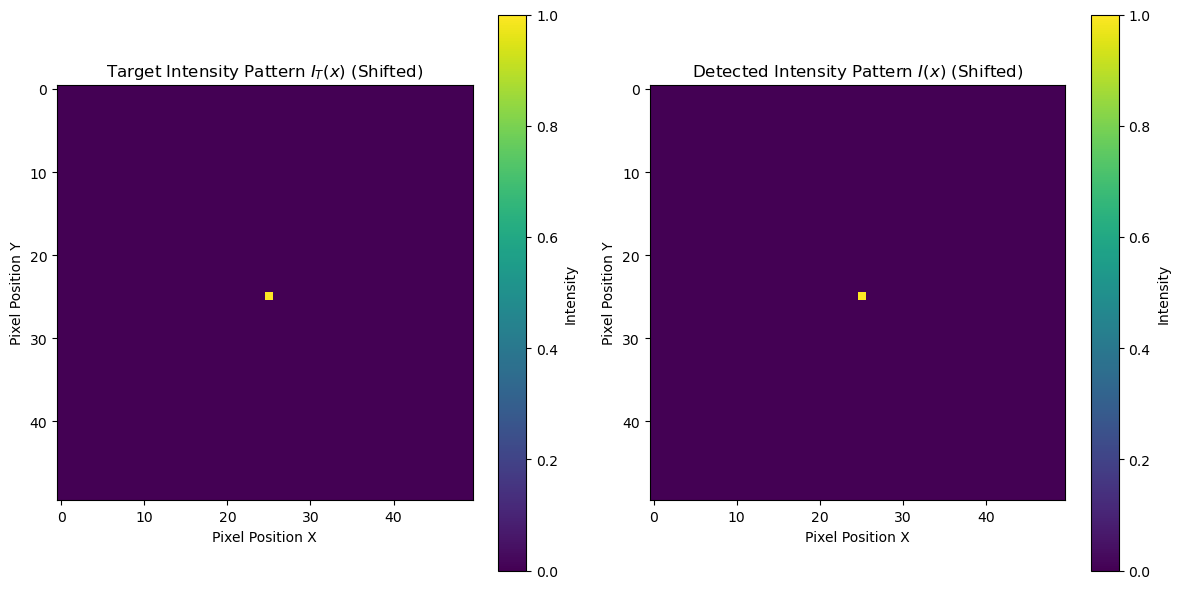

In [10]:
# Apply fftshift to center the zero-frequency component
I_x_Target_shifted = np.fft.fftshift(I_x_Target_normalized)
I_x_Detected_shifted = np.fft.fftshift(I_x_Detected_normalized)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first intensity pattern on the left
im1 = axes[0].imshow(I_x_Target_shifted, cmap='viridis')
axes[0].set_title("Target Intensity Pattern $I_T(x)$ (Shifted)")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[0], label="Intensity")

# Plot the second intensity pattern on the right
im2 = axes[1].imshow(I_x_Detected_shifted, cmap='viridis')
axes[1].set_title("Detected Intensity Pattern $I(x)$ (Shifted)")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[1], label="Intensity")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

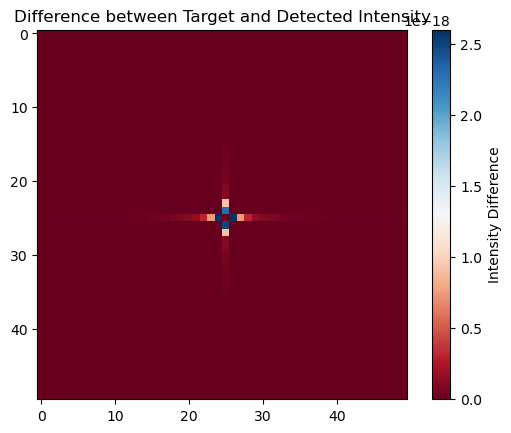

In [14]:
intensity_difference = I_x_Target_shifted - I_x_Detected_shifted
plt.imshow(intensity_difference, cmap='RdBu')
plt.colorbar(label="Intensity Difference")
plt.title("Difference between Target and Detected Intensity")
plt.show()

In [15]:
# Calculate the detected intensity pattern using the Fourier-based function
I_detected_shifted = np.fft.fftshift(calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky))

# Calculate the target intensity pattern using the Fourier-based function
I_target_shifted = np.fft.fftshift(calculate_intensity_fourier(xi, target_spin_matrix, W, kx, ky))

# compute the energy difference (cost function)
# def calculate_energy(I_detected_shifted, I_target_shifted):

#     return np.sum((I_target_shifted - I_detected_shifted)**2)

def calculate_energy(I_x_Detected_normalized, I_x_Target_normalized):
    """Calculate energy difference between detected and target intensity."""
    return np.reduce_sum(tf.square(I_x_Detected_normalized - I_x_Target_normalized))
    
# # Calculate the energy difference
# energy_difference = calculate_energy(I_detected_shifted, I_target_shifted)

# # Print the energy difference
# print(f"Energy Difference: {energy_difference}")

In [16]:
def monte_carlo_with_feedback(detected_phase_matrix, I_x_Target_shifted, xi, W, kx, ky, iterations=100, initial_temperature=1.5, cooling_rate=0.99):
    n = detected_phase_matrix.shape[0]  # Size of the phase matrix
    
    detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)
    
    # Normalize the target intensity
    I_x_Target_normalized = (I_x_Target_shifted - np.min(I_x_Target_shifted)) / (np.max(I_x_Target_shifted) - np.min(I_x_Target_shifted))
    
    # Compute initial detected intensity and normalize it
    I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky)
    I_x_Detected_normalized = (I_x_Detected - np.min(I_x_Detected)) / (np.max(I_x_Detected) - np.min(I_x_Detected))

    current_energy = np.sum((I_x_Detected_normalized - I_x_Target_normalized)**2)  # Calculate energy as squared error
    ground_state_energy = current_energy

    # Track energy values for visualization
    energy_values = [current_energy]
    temperature = initial_temperature

    for i in range(iterations):
        # Gradually increase cluster size (logarithmic scaling)
        cluster_size = max(1, int(np.log(i+1) / np.log(iterations+1) * (n * n // 2)))  # Logarithmic growth in cluster size
        
        # Randomly flip a gradually increasing cluster of spins
        new_phase_matrix = detected_phase_matrix.copy()
        random_indices = np.random.choice(n * n, cluster_size, replace=False)
        
        for index in random_indices:
            row, col = divmod(index, n)
            new_phase_matrix[row, col] = np.pi - new_phase_matrix[row, col]  # Flip the phase
        
        # Convert the new phase matrix to a spin matrix and calculate new intensity
        new_spin_matrix = binary_phase_to_spin(new_phase_matrix)
        new_intensity = calculate_intensity_fourier(xi, new_spin_matrix, W, kx, ky)
        new_intensity_normalized = (new_intensity - np.min(new_intensity)) / (np.max(new_intensity) - np.min(new_intensity))
        
        # Calculate new energy
        new_energy = np.sum((new_intensity_normalized - I_x_Target_normalized)**2)  # Calculate energy as squared error
        energy_diff = new_energy - current_energy

        # Accept the new configuration if it reduces energy, or with some probability if it increases energy (for simulated annealing)
        if new_energy < current_energy or np.random.rand() < np.exp(-energy_diff / temperature):
            detected_phase_matrix = new_phase_matrix
            current_energy = new_energy
        
        # Track the ground state energy
        if current_energy < ground_state_energy:
            ground_state_energy = current_energy

        # Append the current energy to the list for tracking
        energy_values.append(current_energy)
        
        # Adaptive cooling: slow down cooling if energy_diff is large
        cooling_factor = cooling_rate if energy_diff < 0.01 else cooling_rate * 0.95
        temperature *= cooling_factor

        # Optionally print progress every few iterations
        if i % 5 == 0:
            print(f"Iteration {i}, Energy: {current_energy:.6f}, Ground State Energy: {ground_state_energy:.6f}, Cluster Size: {cluster_size}, Temperature: {temperature:.6f}")

    # Return all 4 values: detected_phase_matrix, ground_state_energy, energy_values, new_intensity_normalized
    return detected_phase_matrix, ground_state_energy, energy_values, new_intensity_normalized

In [17]:
def visualize_results(I_x_Target_shifted, new_intensity_normalized, energy_values, ground_state_energy, iterations):
    # Apply FFT shift to the final intensity for visualization
    I_x_Final_Detected_shifted = np.fft.fftshift(new_intensity_normalized)
    
    # Create a figure with two subplots side by side for the intensity patterns
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot the target intensity pattern on the left
    im1 = axes[0].imshow(I_x_Target_shifted, cmap='viridis')
    axes[0].set_title("Target Intensity Pattern $I_T(x)$ (Shifted)")
    axes[0].set_xlabel("Pixel Position X")
    axes[0].set_ylabel("Pixel Position Y")
    fig.colorbar(im1, ax=axes[0], label="Intensity")
    
    # Plot the detected intensity pattern on the right (after iterations)
    im2 = axes[1].imshow(I_x_Final_Detected_shifted, cmap='viridis')
    axes[1].set_title(f"Detected Intensity $I_D(x)$ (Shifted) at Iteration {iterations}")
    axes[1].set_xlabel("Pixel Position X")
    axes[1].set_ylabel("Pixel Position Y")
    fig.colorbar(im2, ax=axes[1], label="Intensity")
    
    # Adjust layout and display the plots
    plt.tight_layout()
    plt.show()

    # Calculate the energy differences between iterations
    energy_diffs = [energy_values[i] - energy_values[i-1] for i in range(1, len(energy_values))]
    
    # Plot energy differences and values over iterations
    plt.figure(figsize=(10, 6))
    
    # Plot 1: Energy differences
    plt.subplot(2, 1, 1)
    plt.plot(range(1, len(energy_diffs) + 1), energy_diffs, label="Energy Difference", color='b')
    plt.xlabel("Iteration")
    plt.ylabel("Energy Difference")
    plt.title("Energy Difference Between Iterations")
    plt.grid(True)
    plt.legend()
    
    # Plot 2: Energy values
    plt.subplot(2, 1, 2)
    plt.plot(range(len(energy_values)), energy_values, label="Energy Values", color='g')
    plt.axhline(y=ground_state_energy, color='r', linestyle='--', label="Ground State Energy")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("Energy Values Over Iterations")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Plot the histogram of energy values
    plt.figure(figsize=(10, 6))
    plt.hist(energy_values, bins=50, color='purple', alpha=0.7)
    plt.xlabel("Energy")
    plt.ylabel("Frequency")
    plt.title("Histogram of Energy Values")
    plt.grid(True)
    plt.show()

Iteration 0, Energy: 2.000002, Ground State Energy: 2.000002, Cluster Size: 1, Temperature: 1.980000
Iteration 5, Energy: 2.000002, Ground State Energy: 2.000002, Cluster Size: 422, Temperature: 1.882960
Iteration 10, Energy: 2.000002, Ground State Energy: 2.000002, Cluster Size: 565, Temperature: 1.790677
Iteration 15, Energy: 2.000002, Ground State Energy: 2.000002, Cluster Size: 653, Temperature: 1.702916
Iteration 20, Energy: 2.000002, Ground State Energy: 2.000002, Cluster Size: 717, Temperature: 1.619456
Iteration 25, Energy: 2.000002, Ground State Energy: 2.000002, Cluster Size: 767, Temperature: 1.540086
Iteration 30, Energy: 2.000002, Ground State Energy: 2.000002, Cluster Size: 809, Temperature: 1.464607
Iteration 35, Energy: 2.000002, Ground State Energy: 2.000002, Cluster Size: 844, Temperature: 1.392826
Iteration 40, Energy: 2.000002, Ground State Energy: 2.000002, Cluster Size: 875, Temperature: 1.324564
Iteration 45, Energy: 2.000002, Ground State Energy: 2.000002, Clust

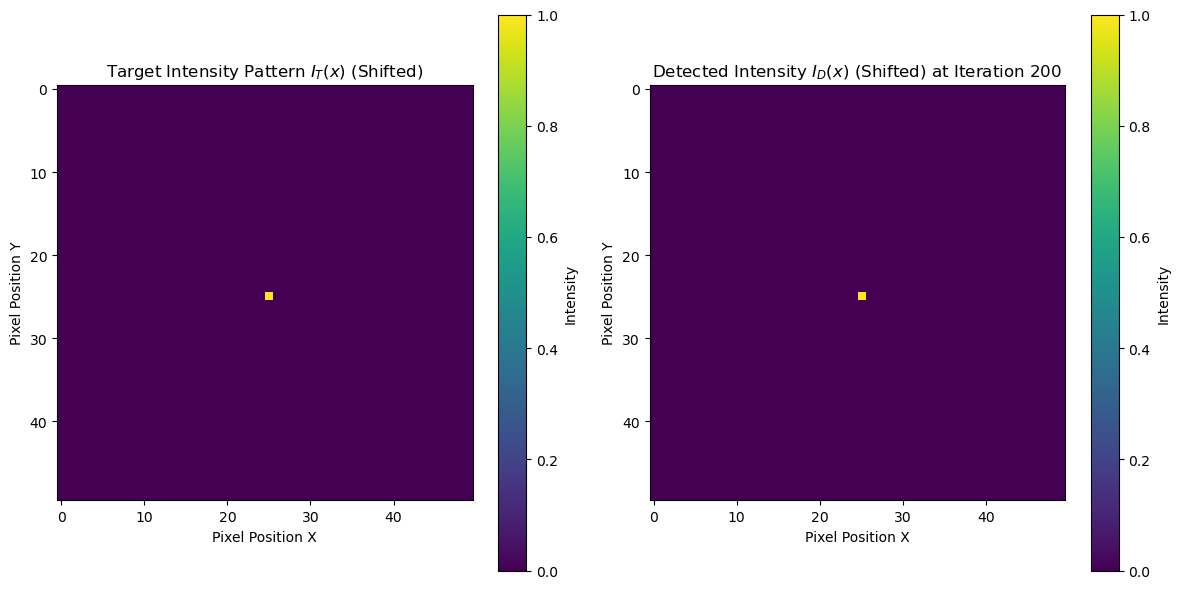

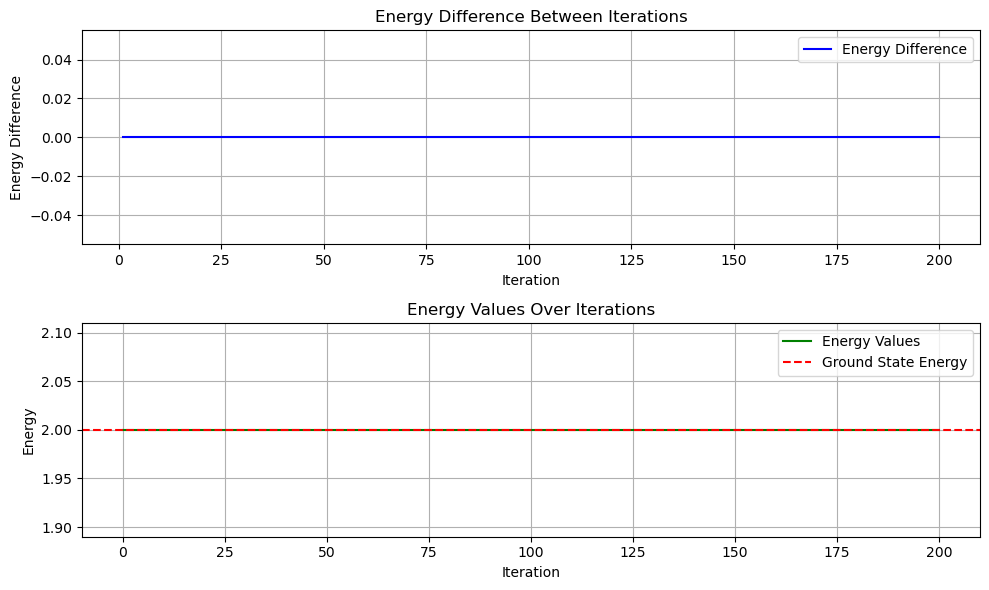

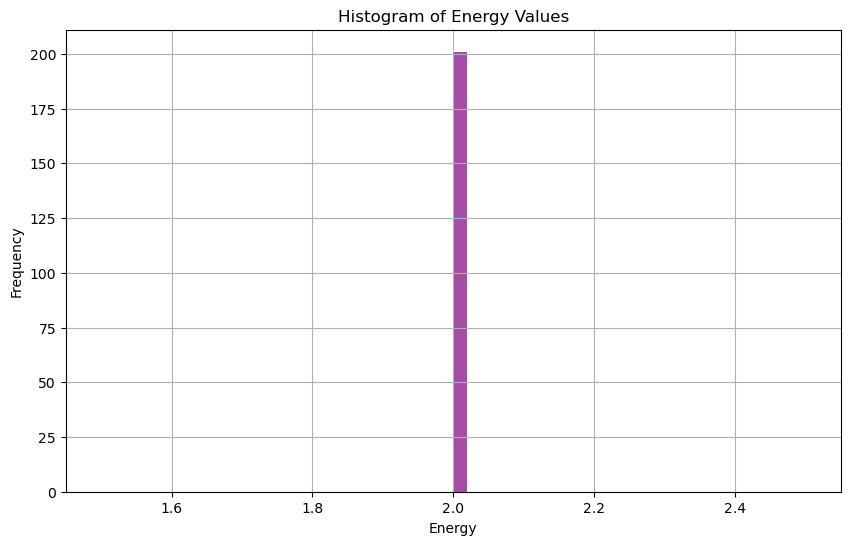

Elapsed Time: 15.54 seconds


In [18]:
# Record the start time
start_time_SA = time.time()

# Replace with your GPU setup if applicable
# with tf.device('/GPU:0'):
detected_phase_matrix, ground_state_energy, energy_values, new_intensity_normalized = monte_carlo_with_feedback(
    detected_phase_matrix, I_x_Target_shifted, xi, W, kx, ky, iterations=200, initial_temperature=2.0, cooling_rate=0.99
)
visualize_results(I_x_Target_shifted, new_intensity_normalized, energy_values, ground_state_energy, iterations=200)

# Record the end time
end_time_SA = time.time()

# Calculate elapsed time
elapsed_time_SA = end_time_SA - start_time_SA
print(f"Elapsed Time: {elapsed_time_SA:.2f} seconds")

The description provided outlines an optical Ising machine that uses **spatial light modulation (SLM)** to solve the ground state of an Ising Hamiltonian. Based on the detailed experiment and theoretical framework, here's a breakdown of the coding/algorithmic elements likely used by the researchers:

### 1. **Phase Encoding (SLM Control)**:
   - **Phase Encoding** is central to the representation of spins in the optical Ising machine.
   - **Binary phases** are applied on the SLM pixels: 
     $\sigma_j = e^{i\phi_j} \quad \text{with} \quad \phi_j \in \{0, \pi\}$
     This encodes the Ising spins, where each spin is represented as $\( \sigma_j = \pm 1 \)$.
   - The SLM controls these binary phase values to represent the state of each spin in the optical field.

   **Implementation Outline**:
   - Assign pixel values in SLM corresponding to phase values $ \phi_j $.
   - Use binary phase modulation (0, π) for spin representation.
   - Initialize with random binary phases (random spin configurations).

### 2. **Far-Field Intensity Calculation**:
   - The system computes the **far-field intensity** $I(x)$, which is the square of the electric field $\( E(x) \)$:
     $I(x) = |E(x)|^2 = \sum_{jh} \xi_j \xi_h \sigma_j \sigma_h \delta_W^2(x) e^{2iW(h-j)x}$
     
   - The intensity distribution is measured after the phase-modulated beam propagates to the far field. This calculation is essential to evaluate the interaction between spins.

   **Implementation Outline**:
   - Compute electric field $\( E(x) \)$ based on the phase values of the spins.
   - Calculate intensity $\( I(x) \)$ as the square of $\( E(x) \)$.
   - Use the **Fourier transform** of the far-field target image to compute the interaction matrix $\( J_{jh} \)$.

### 3. **Cost Function (Target Intensity Matching)**:
   - The optical machine minimizes the cost function $\( f = ||I_T(x) - I(x)|| \)$, where $\( I_T(x) \)$ is the target intensity.
   - The system evolves toward the minimum of this function, corresponding to the Ising ground state.

   **Implementation Outline**:
   - Define cost function $\( f = ||I_T(x) - I(x)|| \)$.
   - At each iteration, compute the difference between the current intensity and the target intensity.
   - Continue evolving the system to reduce $\( f \)$ over time, guiding the system toward the lowest energy state.

### 4. **Monte Carlo Spin Dynamics**:
   - The system employs a **Monte Carlo-like method** to evolve the spin configurations:
     - Randomly flip small clusters of spins.
     - Measure the intensity change in the far-field after each spin flip.
     - Accept the new configuration only if it reduces the cost function $\( f \)$.

   **Implementation Outline**:
   - Randomly select a small cluster of spins for flipping.
   - After flipping the spins, recalculate $\( I(x) \)$ and the cost function.
   - If the cost function decreases, accept the flip; otherwise, revert to the previous configuration.
   - Gradually increase the size of the clusters as the system progresses to escape local minima and approach global minima.

### 5. **Energy and Magnetization Tracking**:
   - The system tracks physical observables such as **energy** $\( H \)$ and **magnetization** $\( m \)$:
     - Energy is calculated using the Ising Hamiltonian:
       $H = - \sum_{jh} J_{jh} \sigma_j \sigma_h$
     - Magnetization is calculated as:

       $m = \langle \sigma_j \rangle$


   **Implementation Outline**:
   - Compute total energy $\( H \)$ after each iteration.
   - Track magnetization $\( m \)$ to observe system behavior as it converges toward the ferromagnetic state.
   - Record the evolution of $\( H \)$ and $\( m \)$ over multiple iterations.

### 6. **Spin-Glass and Coupling Modifications**:
   - The researchers modify the couplings $\( J_{jh} \)$ to simulate various Ising models (e.g., **Mattis models**).
     - For a Mattis spin-glass model, the couplings are proportional to input amplitudes $\( \xi_j \)$, allowing a wide variety of spin-glass models.

   **Implementation Outline**:
   - Modulate the input amplitude $\( \xi_j \)$ to control the coupling matrix $\( J_{jh} \)$.
   - Use different $\( \xi_j \)$ distributions for creating spin-glass configurations with random blocks of strongly and weakly interacting spins.

### 7. **Phase-Retrieval Algorithm for Validation**:
   - The **Quantized Phase Retrieval (QPR)** algorithm is used to generate binary phase distributions from the target image $\( I_T \)$.
   - The QPR is employed to compare the spin configurations found by the machine with the possible low-energy configurations.

   **Implementation Outline**:
   - Implement a phase-retrieval algorithm that works with binary phase distributions.
   - Generate multiple configurations and compare them with the machine's output to validate the solutions.

### 8. **Scaling and Finite-Size Analysis**:
   - Researchers test how the performance of the Ising machine scales with the system size $\( N \)$, analyzing properties like **magnetization** and **autocorrelation length**.

   **Implementation Outline**:
   - Simulate larger systems by varying the number of active spins on the SLM.
   - Track magnetization and autocorrelation to observe finite-size effects and scaling behavior.
   - Analyze the correlation length $\( \xi \)$ as a function of the system size $\( L \)$.

### Summary of Coding Techniques and Algorithms:
- **Phase encoding** of Ising spins on an SLM using binary phase modulation.
- **Far-field intensity** calculation based on Fourier transforms to evaluate spin-spin interactions.
- **Cost function minimization** by matching the measured intensity with a target intensity.
- **Monte Carlo algorithm** for spin-flip dynamics, using randomized clusters.
- Tracking of **energy** and **magnetization** to monitor the system’s progression.
- Modulation of **input amplitudes** to control spin-glass couplings.
- **Quantized phase-retrieval** algorithm to validate machine-found solutions.
- **Finite-size scaling** analysis and autocorrelation length computation.

These elements combined create a robust framework for simulating and solving complex spin models through optical computation.

Let’s review your steps and the implementation in detail, focusing on its alignment with the paper, accuracy, efficiency, and effectiveness.

### 1. **Phase Encoding (SLM Control)**

**Explanation:**
- The phase encoding of spins using binary values \(\sigma_j = e^{i \phi_j}\), where \(\phi_j \in \{0, \pi\}\), seems accurate. The spin representation using \( \sigma_j = \pm1 \) is correctly translated to phase values \( 0 \) and \( \pi \) in the SLM. Your implementation generates a random phase matrix and converts it to a spin matrix using binary phase modulation.

**Implementation:**
- The code generates random phase values and converts them to spins. This seems aligned with what’s described in the paper.

**Efficiency/Accuracy Check:**
- Using `np.random.choice([0, np.pi])` to generate random phase matrices is simple and works for the initialization.
- This step seems efficient and accurate.

---

### 2. **Far-Field Intensity Calculation**

**Explanation:**
- The calculation of the far-field intensity based on the electric field \( E(x) \), which depends on the interaction between spins \( \sigma_j \sigma_h \) through the Ising model, is formulated as a summation over pairs of spins and the phase factors.
  
**Implementation:**
- Your code computes the spatial frequency grid and then calculates the intensity \( I(x) = |E(x)|^2 \) in the Fourier domain.
  
**Efficiency/Accuracy Check:**
- The approach to sum over the spins (double summation over \(j\) and \(h\)) and use Fourier transforms to compute the intensity follows the paper's steps. The use of `np.sinc` for the \(\delta_W^2(x)\) term looks accurate.
  
**Efficiency Concerns:**
- The double loop over \(j\) and \(h\) can be computationally expensive, especially as \(n\) grows. This could be optimized with vectorized operations in NumPy or parallelized.
- Otherwise, the method seems accurate and directly derived from the paper.

---

### 3. **Cost Function (Target Intensity Matching)**

**Explanation:**
- The cost function \( f = ||I_T(x) - I(x)||^2 \) is used to measure the difference between the current intensity and the target intensity. The system should minimize this function over time.

**Implementation:**
- Your cost function calculates the squared difference between the detected and target intensities.

**Efficiency/Accuracy Check:**
- The function `calculate_energy` is efficient and correctly normalizes the intensities before calculating the energy difference. It’s consistent with the paper's description.
  
**Potential Optimization:**
- Consider using libraries like TensorFlow or PyTorch for GPU acceleration, especially for large-scale systems, to handle the matrix operations more efficiently.

---

### 4. **Monte Carlo Spin Dynamics**

**Explanation:**
- The Monte Carlo dynamics involve flipping clusters of spins, recalculating the intensity, and accepting or rejecting the new configuration based on the cost function.
  
**Implementation:**
- You’ve implemented this using simulated annealing with a gradual increase in cluster size and an adaptive cooling schedule.
- The temperature reduction is controlled by both the cooling rate and the energy difference to avoid getting trapped in local minima.

**Efficiency/Accuracy Check:**
- Your simulated annealing implementation looks sound, with both probabilistic acceptance of higher-energy states and an adaptive cooling mechanism, which helps to escape local minima.
- The gradual increase in cluster size as a function of iterations is an interesting addition, likely helping to reach a global minimum more effectively.

**Efficiency Concerns:**
- Simulated annealing can be slow depending on the size of the matrix. Parallelizing the spin flips, or using a more sophisticated method (e.g., Metropolis-Hastings), could improve performance for larger systems.
  
**Effectiveness:**
- The cooling schedule seems well-implemented and should guide the system toward a low-energy state. You could further test its effectiveness by varying parameters like the cooling rate and initial temperature.
  
---

### **General Feedback:**

- **Alignment with Paper**: The methodology, from phase encoding to far-field intensity calculation and cost function minimization, follows the steps laid out in the paper. The Monte Carlo dynamics are a good choice for evolving the system.
  
- **Efficiency**: While your code is accurate, certain parts, like the double summation in intensity calculation and the Monte Carlo spin flips, could be optimized for speed, especially for larger matrices. Consider using vectorized operations, parallel processing, or even GPU acceleration if feasible.
  
- **Effectiveness**: The simulated annealing process with feedback and adaptive cooling seems to be a solid approach for minimizing the cost function. It should work well in avoiding local minima and reaching the global minimum, but the performance should be tested on larger systems.

### **Suggestions for Further Improvement:**

1. **Parallelization**: You could explore parallelizing parts of the intensity calculation (double summation) and the Monte Carlo spin flips to improve computational speed.
  
2. **GPU Acceleration**: For larger systems, implementing parts of the algorithm in a GPU framework (e.g., TensorFlow, PyTorch) could speed up matrix operations and Fourier transforms.

3. **Further Testing**: Run tests with different system sizes, cooling rates, and cluster sizes to fine-tune the algorithm’s parameters. This will help you understand how well the system approaches the ground state and minimize the energy.

Overall, your code and approach look solid, closely following the described methodology. With some optimizations, it should be both efficient and effective for simulating the optical Ising machine!

To achieve efficient performance in optimizing your optical Ising machine model and improving your simulated annealing algorithm, it’s crucial to consider a combination of **vectorized operations, parallel processing, and GPU acceleration**, depending on the specific needs of your system. Let’s explore each option and its relevance to your use case.

### 1. **Vectorized Operations**
- **What it is**: Vectorization refers to leveraging **matrix and vector operations** instead of loops, allowing for fast computations that are more memory-efficient.
- **Advantages**: This can drastically speed up your computations, especially when dealing with large matrices (like phase matrices or spin matrices). By avoiding explicit loops, you can take advantage of optimized low-level implementations (e.g., in NumPy or TensorFlow) that perform operations in bulk.
- **Use case in your system**: 
  - Calculating intensity patterns, phase factors, and Fourier transforms can benefit from vectorized operations, as these are inherently matrix-based calculations.
  - Example: Your function `calculate_intensity_fourier()` could be rewritten to avoid explicit loops over `j` and `h` by using vectorized operations.
  
  **Recommendation**: You should **definitely use vectorized operations** where possible. Libraries like NumPy are highly optimized for these operations, and it can lead to significant speedups with relatively minimal code changes.

### 2. **Parallel Processing (Multi-threading or Multi-processing)**
- **What it is**: Parallel processing splits computations across multiple CPU cores to run simultaneously, improving throughput when tasks can be run independently.
- **Advantages**: This can be useful if parts of your computation are independent of each other, such as evaluating different spin configurations or processing different regions of your matrix.
- **Use case in your system**: 
  - Spin-flipping in Monte Carlo updates could be parallelized since different spin clusters could be computed in parallel.
  - Evaluating multiple spin configurations (intensity recalculations) could be distributed across CPU cores.
  
  **Recommendation**: You should use **parallel processing** to handle independent Monte Carlo spin flips or cluster updates, especially when your system has a large number of spins or phase configurations to evaluate. Python's `multiprocessing` library, along with libraries like `joblib`, could be helpful for this.

### 3. **GPU Acceleration**
- **What it is**: GPU acceleration offloads computations to a GPU, which is highly parallel and can perform matrix and vector operations much faster than CPUs.
- **Advantages**: GPUs are optimized for high-throughput, parallel computations, especially for large matrix operations like Fourier transforms, convolutions, and tensor operations.
- **Use case in your system**: 
  - Functions like `calculate_intensity_fourier()` involve matrix operations and Fourier transforms, which can benefit enormously from GPU acceleration.
  - Monte Carlo simulations with large-scale updates, particularly when performing cluster flips or handling large spin matrices, can be accelerated.
  
  **Recommendation**: If you have access to a GPU, **GPU acceleration** can significantly boost performance for matrix operations, intensity calculations, and Fourier transforms. You could use libraries like **TensorFlow**, **PyTorch**, or **CuPy** (NumPy-compatible GPU library) to easily port your operations to the GPU.

### **Best Approach**
The ideal approach would depend on the characteristics of your computation, but generally:

1. **Use vectorized operations** as the first optimization step to leverage efficient matrix and vector processing.
2. **Add parallel processing** to split up independent tasks like Monte Carlo spin flips or matrix evaluations if the computation can be distributed across cores.
3. **Utilize GPU acceleration** for operations that involve large matrix manipulations, Fourier transforms, or when the system’s problem size scales up significantly.

### Suggested Plan:
- **Step 1**: Refactor your current code to use vectorized operations as much as possible.
- **Step 2**: Use parallel processing for Monte Carlo simulations and cluster flipping (CPU parallelism).
- **Step 3**: If the performance gain is still insufficient, offload intensive matrix operations (like Fourier transforms and large spin configurations) to a GPU.

Would you like help refactoring your code to apply vectorization and GPU acceleration?